In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize']=(10,5)
pd.set_option("display.max_columns", None)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
os.getcwd()
print(os.listdir("/content"))
os.chdir('/content/drive/MyDrive/Airbnb_2')
os.getcwd()

['.config', 'drive', 'sample_data']


'/content/drive/MyDrive/Airbnb_2'

In [ ]:
Rbnb = '/content/MyDrive/drive/MyDrive/Airbnb_2'

# Exploration

In [ ]:
airbnb = pd.read_csv("data/airbnb_train.csv")
airbnb_test=pd.read_csv("data/airbnb_test.csv")
print(f"Il y a {airbnb.shape[0]} logements pour {airbnb.shape[1]} colonnes")
airbnb.head()

Il y a 22234 logements pour 28 colonnes


,id,log_price,property_type,room_type,amenities,accommodates,bathrooms,bed_type,cancellation_policy,cleaning_fee,...,last_review,latitude,longitude,name,neighbourhood,number_of_reviews,review_scores_rating,zipcode,bedrooms,beds
0,5708593,4.317488,House,Private room,"{TV,""Wireless Internet"",Kitchen,""Free parking ...",3,1.0,Real Bed,flexible,False,...,NaN,33.782712,-118.134410,Island style Spa Studio,Long Beach,0,NaN,90804,0.0,2.0
1,14483613,4.007333,House,Private room,"{""Wireless Internet"",""Air conditioning"",Kitche...",4,2.0,Real Bed,strict,False,...,2017-09-17,40.705468,-73.909439,"Beautiful and Simple Room W/2 Beds, 25 Mins to...",Ridgewood,38,86.0,11385,1.0,2.0
2,10412649,7.090077,Apartment,Entire home/apt,"{TV,""Wireless Internet"",""Air conditioning"",Kit...",6,2.0,Real Bed,flexible,False,...,NaN,38.917537,-77.031651,2br/2ba luxury condo perfect for infant / toddler,U Street Corridor,0,NaN,20009,2.0,2.0
3,17954362,3.555348,House,Private room,"{TV,""Cable TV"",Internet,""Wireless Internet"",""A...",1,1.0,Real Bed,flexible,True,...,2017-09-29,40.736001,-73.924248,Manhattan view from Queens. Lovely single room .,Sunnyside,19,96.0,11104,1.0,1.0
4,9969781,5.480639,House,Entire home/apt,"{TV,""Cable TV"",Internet,""Wireless Internet"",Ki...",4,1.0,Real Bed,moderate,True,...,2017-08-28,37.744896,-122.430665,Zen Captured Noe Valley House,Noe Valley,15,96.0,94131,2.0,2.0


In [ ]:
print("Colonnes du dataset :")
airbnb.columns


Colonnes du dataset :


Index(['id', 'log_price', 'property_type', 'room_type', 'amenities',
       'accommodates', 'bathrooms', 'bed_type', 'cancellation_policy',
       'cleaning_fee', 'city', 'description', 'first_review',
       'host_has_profile_pic', 'host_identity_verified', 'host_response_rate',
       'host_since', 'instant_bookable', 'last_review', 'latitude',
       'longitude', 'name', 'neighbourhood', 'number_of_reviews',
       'review_scores_rating', 'zipcode', 'bedrooms', 'beds'],
      dtype='object')

Type de données contenues dans le dataset

In [ ]:
airbnb.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22234 entries, 0 to 22233
Data columns (total 28 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   id                      22234 non-null  int64  
 1   log_price               22234 non-null  float64
 2   property_type           22234 non-null  object 
 3   room_type               22234 non-null  object 
 4   amenities               22234 non-null  object 
 5   accommodates            22234 non-null  int64  
 6   bathrooms               22183 non-null  float64
 7   bed_type                22234 non-null  object 
 8   cancellation_policy     22234 non-null  object 
 9   cleaning_fee            22234 non-null  bool   
 10  city                    22234 non-null  object 
 11  description             22234 non-null  object 
 12  first_review            17509 non-null  object 
 13  host_has_profile_pic    22178 non-null  object 
 14  host_identity_verified  22178 non-null

On voit que la majorité des données stockées sont de type 'object'.

Nombre de valeurs nulles dans le dataset (par colonne)

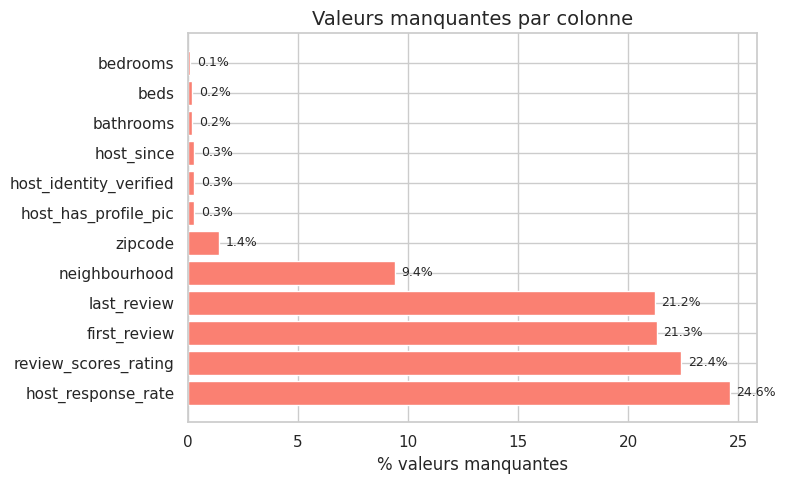

In [ ]:
missing=airbnb.isnull().sum()
missing_pourcent=(missing/len(airbnb)*100).round(1) #calcul du pourcentage de valeurs manquantes
missing_dataframe=pd.DataFrame({'nb de valeurs manquantes' : missing, '%':missing_pourcent}) #nouveau DataFrame pour visualiser les valeurs manquantes
missing_dataframe=missing_dataframe[missing_dataframe['nb de valeurs manquantes']>0].sort_values('%', ascending=False)

#graphe pour rendre les observations plus visuelles
fig, axes=plt.subplots(figsize=(8,5))
graphe_barres=axes.barh(missing_dataframe.index, missing_dataframe['%'], color='salmon',edgecolor='white')
axes.set_xlabel('% valeurs manquantes')
axes.set_title('Valeurs manquantes par colonne', fontsize=14)
for barre, valeur in zip(graphe_barres, missing_dataframe['%']):
    axes.text(barre.get_width()+0.3, barre.get_y()+barre.get_height()/2,f'{valeur}%',va='center', fontsize=9) #ajout du texte à côté de chaque barre
plt.tight_layout() #ajustement des espacements pour la lisibilité
plt.show()

On remarque que dans les colonnes first_review, host_response_rate et last_review, les valeurs nulles sont importantes. On va donc regarder le pourcentage de valeurs nulles pour ces colonnes.

In [ ]:
n = len(airbnb)

print(f"Pourcentage de valeurs nulles dans 'first_review' : {airbnb['first_review'].isnull().sum()/n}")
print(f"Pourcentage de valeurs nulles dans 'host_response_rate' : {airbnb['host_response_rate'].isnull().sum()/n}")
print(f"Pourcentage de valeurs nulles dans 'last_review' : {airbnb['last_review'].isnull().sum()/n}")

Pourcentage de valeurs nulles dans 'first_review' : 0.2125123684447243
Pourcentage de valeurs nulles dans 'host_response_rate' : 0.24624449042007737
Pourcentage de valeurs nulles dans 'last_review' : 0.21210758298102006


Le pourcentage de valeurs nulles étant assez important, on décide donc de drop les colonnes concernées.
On drop aussi 'description', car on sait d'ores et déjà qu'elle ne permettra pas d'améliorer les prédictions : aucune information utile sur l'appartement n'est donnée.

In [ ]:
airbnb.drop(columns=["first_review", "host_response_rate", "last_review"], axis=1, inplace=True)
airbnb.drop("description", axis=1, inplace=True)
airbnb.columns

Index(['id', 'log_price', 'property_type', 'room_type', 'amenities',
       'accommodates', 'bathrooms', 'bed_type', 'cancellation_policy',
       'cleaning_fee', 'city', 'host_has_profile_pic',
       'host_identity_verified', 'host_since', 'instant_bookable', 'latitude',
       'longitude', 'name', 'neighbourhood', 'number_of_reviews',
       'review_scores_rating', 'zipcode', 'bedrooms', 'beds'],
      dtype='object')

Affichage de statistiques génériques (count, moyenne, écart-type, nombre d'élements uniques...)

In [ ]:
airbnb.describe(include="all")

,id,log_price,property_type,room_type,amenities,accommodates,bathrooms,bed_type,cancellation_policy,cleaning_fee,...,instant_bookable,latitude,longitude,name,neighbourhood,number_of_reviews,review_scores_rating,zipcode,bedrooms,beds
count,2.223400e+04,22234.000000,22234,22234,22234,22234.000000,22183.000000,22234,22234,22234,...,22234,22234.000000,22234.000000,22234,20148,22234.000000,17256.000000,21931,22208.000000,22199.000000
unique,NaN,NaN,31,3,21160,NaN,NaN,5,5,2,...,2,NaN,NaN,22155,558,NaN,NaN,674,NaN,NaN
top,NaN,NaN,Apartment,Entire home/apt,{},NaN,NaN,Real Bed,strict,True,...,f,NaN,NaN,East Village Studio,Williamsburg,NaN,NaN,11211.0,NaN,NaN
freq,NaN,NaN,14635,12348,161,NaN,NaN,21622,9726,16401,...,16401,NaN,NaN,4,878,NaN,NaN,425,NaN,NaN
mean,1.122269e+07,4.783481,NaN,NaN,NaN,3.155573,1.236037,NaN,NaN,NaN,...,NaN,38.462971,-92.269305,NaN,NaN,20.670774,94.069077,NaN,1.264769,1.711473
std,6.080480e+06,0.718758,NaN,NaN,NaN,2.143870,0.586246,NaN,NaN,NaN,...,NaN,3.071679,21.670081,NaN,NaN,37.183731,7.782235,NaN,0.852819,1.254903
min,3.362000e+03,2.302585,NaN,NaN,NaN,1.000000,0.000000,NaN,NaN,NaN,...,NaN,33.339002,-122.510940,NaN,NaN,0.000000,20.000000,NaN,0.000000,0.000000
25%,6.202924e+06,4.317488,NaN,NaN,NaN,2.000000,1.000000,NaN,NaN,NaN,...,NaN,34.136082,-118.340633,NaN,NaN,1.000000,92.000000,NaN,1.000000,1.000000
50%,1.217425e+07,4.700480,NaN,NaN,NaN,2.000000,1.000000,NaN,NaN,NaN,...,NaN,40.662632,-76.994944,NaN,NaN,6.000000,96.000000,NaN,1.000000,1.000000
75%,1.639502e+07,5.220356,NaN,NaN,NaN,4.000000,1.000000,NaN,NaN,NaN,...,NaN,40.746358,-73.954599,NaN,NaN,23.000000,100.000000,NaN,1.000000,2.000000


On remarque que pour certaines colonnes (bed_type, host_identity_verified par ex.), il y a une valeur qui ressort souvent. Dans les parties qui vont suivre, on va essayer de voir la fréquence d'apparition de ces valeurs afin de les éliminer ou non.

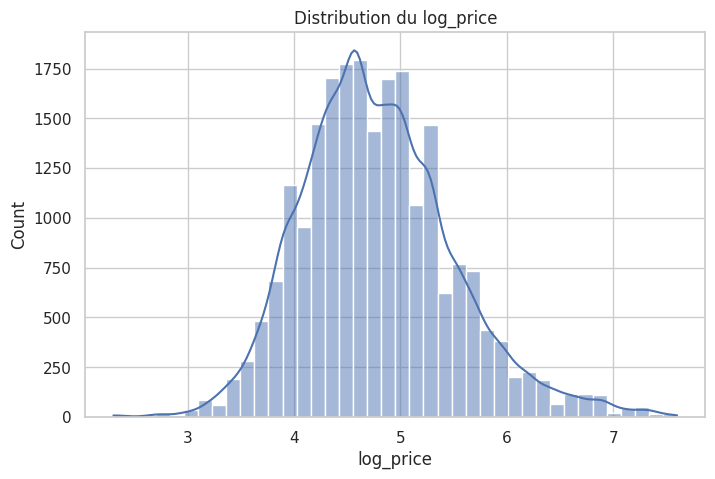

In [13]:
plt.figure(figsize=(8,5))
sns.histplot(airbnb['log_price'], bins=40, kde=True)
plt.title("Distribution du log_price")
plt.show()

## Analyse de la distribution des prix

On observe que la variable `log_price` suit une distribution relativement proche d’une loi normale.

L’utilisation du logarithme du prix permet de réduire l’impact des valeurs extrêmes présentes dans les prix Airbnb. Sans cette transformation, quelques logements très chers pourraient fortement perturber les modèles de régression.

Cette transformation rend également les relations entre variables plus linéaires, ce qui améliore généralement les performances des modèles de machine learning.

Ce graphique montre :

la répartition des prix,
la présence ou non d’outliers,
si la target est exploitable pour une régression

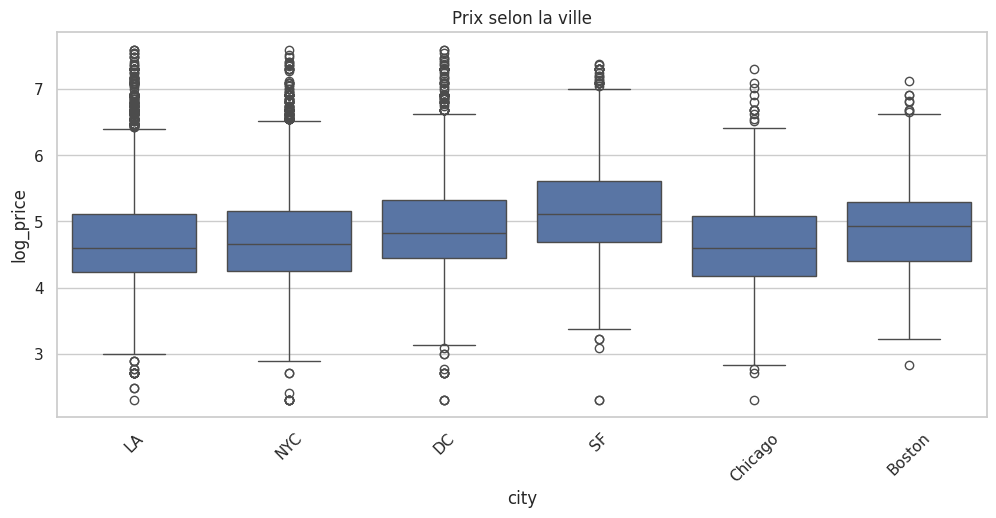

In [14]:
plt.figure(figsize=(12,5))
sns.boxplot(data=airbnb, x='city', y='log_price')
plt.xticks(rotation=45)
plt.title("Prix selon la ville")
plt.show()

## Influence de la ville sur le prix

Ce graphique montre que le prix des logements varie fortement selon la ville.

Certaines villes présentent :
- une médiane de prix plus élevée
- une plus grande dispersion des prix
- davantage de logements très chers

La variable `city` semble donc être une caractéristique importante pour prédire le prix d’un logement Airbnb.

Cela justifie sa conservation dans le modèle de prédiction.

Il permet :

d’identifier une variable importante
de justifier le feature engineering
de motiver l’encodage des villes

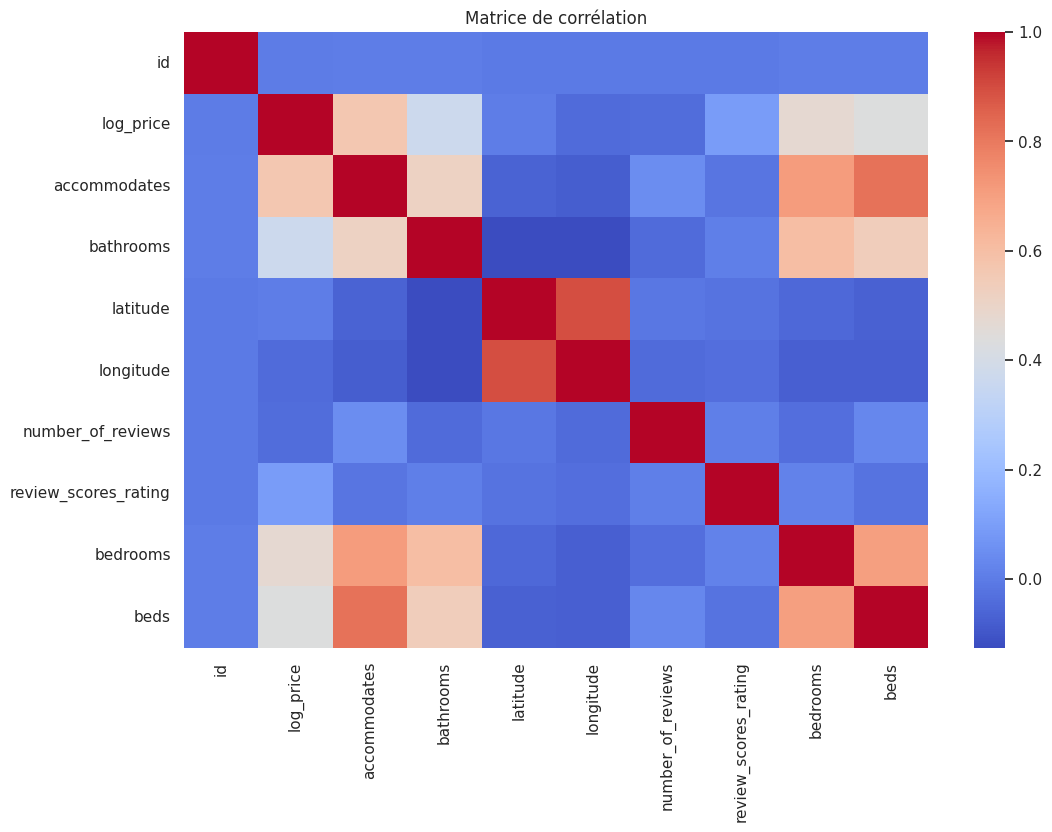

In [15]:
numeric_cols = airbnb.select_dtypes(include=np.number)

plt.figure(figsize=(12,8))
sns.heatmap(numeric_cols.corr(), cmap='coolwarm')
plt.title("Matrice de corrélation")
plt.show()

## Corrélations entre variables numériques

La matrice de corrélation permet d’identifier les relations entre les différentes variables numériques.

On observe notamment que certaines caractéristiques comme :
- le nombre de personnes accueillies (`accommodates`)
- le nombre de chambres
- le nombre de lits

semblent positivement corrélées avec le prix du logement.

Cette analyse permet :
- d’identifier les variables les plus utiles
- de détecter d’éventuelles redondances entre variables
- de mieux comprendre les facteurs influençant les prix.

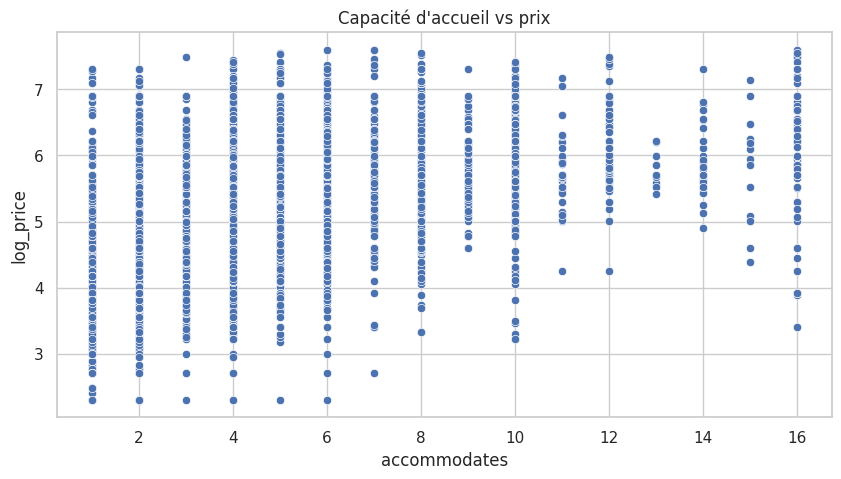

In [16]:
sns.scatterplot(data=airbnb, x='accommodates', y='log_price')
plt.title("Capacité d'accueil vs prix")
plt.show()

## Relation entre capacité d’accueil et prix

On observe une tendance générale : plus un logement peut accueillir de personnes, plus son prix augmente.

La relation n’est cependant pas parfaitement linéaire, ce qui suggère que d’autres variables influencent également fortement le prix :
- la localisation
- les équipements
- le type de logement
- les notes des utilisateurs

Cette variable reste néanmoins pertinente pour la prédiction.

In [17]:
errors = y_test - y_pred_test

sns.histplot(errors, bins=40)
plt.title("Distribution des erreurs")
plt.show()

NameError: name 'y_test' is not defined

## Analyse des erreurs du modèle

La distribution des erreurs permet d’évaluer la qualité globale du modèle.

Un bon modèle produit généralement :
- des erreurs centrées autour de zéro
- une distribution relativement symétrique
- peu de valeurs extrêmes

Les erreurs importantes peuvent correspondre à des logements atypiques ou à des informations insuffisantes dans les données.

In [ ]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_test)
plt.xlabel("Valeurs réelles")
plt.ylabel("Prédictions")
plt.title("Prédictions vs réalité")
plt.show()

## Comparaison entre valeurs réelles et prédictions

Ce graphique compare les valeurs réelles aux prédictions du modèle.

Si les prédictions étaient parfaites, tous les points seraient alignés sur une diagonale.

On observe ici que le modèle capture correctement la tendance générale mais présente encore certaines erreurs sur des logements particuliers.

Ce graphique permet de visualiser :
- la précision globale du modèle
- les éventuels biais
- la dispersion des prédictions.

Fréquence d'apparition des valeurs dites 'top' dans les colonnes éligibles (sans compter les valeurs nulles)

In [ ]:
n = len(airbnb)

print(f"Pourcentage d'apparition de 'Real Bed' dans bed_type : {sum(airbnb[airbnb['bed_type'] == 'Real Bed'].count())/airbnb['bed_type'].count()}")
print(f"Pourcentage d'apparition de 'Entire home/apt' dans room_type : "
      f"{sum(airbnb[airbnb['room_type'] == 'Entire home/apt'].count())/airbnb['room_type'].count()}")
print(f"Pourcentage d'apparition de 'strict' dans bed_type : {sum(airbnb[airbnb['cancellation_policy'] == 'strict'].count())/airbnb['cancellation_policy'].count()}")
print(f"Pourcentage d'apparition de 'True' dans cleaning_fee : {sum(airbnb[airbnb['cleaning_fee'] == True].count())/airbnb['cleaning_fee'].count()}")
print(f"Pourcentage d'apparition de 't' dans host_has_profile_pic : "
      f"{sum(airbnb[airbnb['host_has_profile_pic'] == 't'].count())/airbnb['host_has_profile_pic'].count()}")
print(f"Pourcentage d'apparition de 't' dans host_identity_verified : "
      f"{sum(airbnb[airbnb['host_identity_verified'] == 't'].count())/airbnb['host_identity_verified'].count()}")
print(f"Pourcentage d'apparition de 'f' dans instant_bookable : {sum(airbnb[airbnb['instant_bookable'] == 'f'].count())/airbnb['instant_bookable'].count()}")
print(f"Pourcentage d'apparition de 'Williamsburg' dans neighbourhood : "
      f"{sum(airbnb[airbnb['neighbourhood'] == 'Williamsburg'].count())/airbnb['neighbourhood'].count()}")


Pourcentage d'apparition de 'Real Bed' dans bed_type : 23.004947377889717
Pourcentage d'apparition de 'Entire home/apt' dans room_type : 13.160295043626878
Pourcentage d'apparition de 'strict' dans bed_type : 10.390078258522983
Pourcentage d'apparition de 'True' dans cleaning_fee : 17.496986597103536
Pourcentage d'apparition de 't' dans host_has_profile_pic : 23.59040490576247
Pourcentage d'apparition de 't' dans host_identity_verified : 16.001668319956714
Pourcentage d'apparition de 'f' dans instant_bookable : 17.445893676351535
Pourcentage d'apparition de 'Williamsburg' dans neighbourhood : 1.0357851895969823


On remarque que certains pourcentages sont très importants

Vérification des colonnes dont le contenu ne peut pas être traité par un algorithme

In [ ]:
rooms = airbnb["room_type"].unique()
beds_type = airbnb["bed_type"].unique()
cancellation = airbnb["cancellation_policy"].unique()
verified = airbnb["host_identity_verified"].unique()
online_booking = airbnb["instant_bookable"].unique()
cities = airbnb["city"].unique()
properties = airbnb["property_type"].unique()

for i in range(2,airbnb.shape[1]):
    print(f"{airbnb.columns[i]} : {airbnb.iloc[:,i].unique()}")

print("Types de propriétés : ", properties)
print(f"Type de chambres : {rooms}")
print(f"Type de lits : {beds_type}")
print(f"Conditions d'annulation : {cancellation}")
print(f"Identité vérifiée : {verified}")
print(f"Réservation en ligne : {online_booking}")
print(f"Villes : {cities}")


property_type : ['House' 'Apartment' 'Townhouse' 'Guest suite' 'Condominium' 'Timeshare'
 'Chalet' 'Guesthouse' 'Bungalow' 'Loft' 'In-law' 'Boat' 'Dorm' 'Other'
 'Bed & Breakfast' 'Camper/RV' 'Villa' 'Boutique hotel' 'Cabin' 'Hostel'
 'Hut' 'Yurt' 'Serviced apartment' 'Castle' 'Vacation home' 'Tent' 'Cave'
 'Tipi' 'Earth House' 'Island' 'Treehouse']
room_type : ['Private room' 'Entire home/apt' 'Shared room']
amenities : ['{TV,"Wireless Internet",Kitchen,"Free parking on premises","Pets allowed","Suitable for events",Washer,Dryer,"Smoke detector",Essentials,Shampoo,"Lock on bedroom door",Hangers,"Hair dryer",Iron}'
 '{"Wireless Internet","Air conditioning",Kitchen,Heating,"Family/kid friendly","Smoke detector","Carbon monoxide detector","Fire extinguisher",Essentials,"Lock on bedroom door","24-hour check-in","Hair dryer",Iron,"translation missing: en.hosting_amenity_50","Self Check-In",Keypad,"Bed linens",Microwave,"Coffee maker",Refrigerator,"Dishes and silverware","Cooking basics",Ov

On peut transformer ces colonnes en index pour simplifier le traitement de l'information par l'algorithme : c'est la prochaine étape de ce notebook.

# Entraînement

### Remplacer le type de propriété par un indice, cela permet à l’algo de l’utiliser

In [ ]:
class CustomTransformation():

    def __init__(self):
        """
        Class simple pour convertir les type de propriétés en des indices numériques, utilisable pour un algo de machine learning
        """

        self.fitted = False # Indique si fit_transform a été utilisé, pour éviter d’utiliser transform sans que fit ait été appelé
        self.property2index = dict()# Dictionnaire qui va convertir le nom en indice
        self.rooms2index = dict()
        self.beds2index = dict()
        self.cancel2index = dict()
        self.online2index = dict()
        self.cities2index = dict()

        self.tf2index = {'t':True, 'f':False}

        self.max_index_prop = 0 # Indique le dernier indice de la propriété.
        self.max_index_rooms = 0
        self.max_index_beds = 0
        self.max_index_cancel = 0
        self.max_index_online = 0
        self.max_index_cities = 0

    def fit_transform(self, dataset):

        self.fitted = True

        # Récupère les types de propriété (maison, appart etc...)


        self.property2index = {prop:i for (i, prop) in enumerate(properties)}
        self.max_index_prop = max(list(self.property2index.values()))

        self.rooms2index = {r:i for (i, r) in enumerate(rooms)}
        self.max_index_rooms = max(list(self.rooms2index.values()))

        self.beds2index = {b:i for (i, b) in enumerate(beds_type)}
        self.max_index_beds = max(list(self.beds2index.values()))

        self.cancel2index = {can:i for (i, can) in enumerate(cancellation)}
        self.max_index_cancel = max(list(self.cancel2index.values()))

        self.online2index = {on:i for (i, on) in enumerate(online_booking)}
        self.max_index_online = max(list(self.online2index.values()))

        self.cities2index = {cit:i for (i, cit) in enumerate(cities)}
        self.max_index_cities = max(list(self.cities2index.values()))
        # transform
        return self.transform(dataset)

    def transform(self, dataset):
        # Transform les propriétés en indice
        dataset.loc[:, "property_type"] = dataset["property_type"].replace(self.property2index)
        dataset.loc[:, "room_type"] = dataset["room_type"].replace(self.rooms2index)
        dataset.loc[:, "bed_type"] = dataset["bed_type"].replace(self.beds2index)
        dataset.loc[:, "cancellation_policy"] = dataset["cancellation_policy"].replace(self.cancel2index)
        dataset.loc[:, "instant_bookable"] = dataset["instant_bookable"].replace(self.online2index)
        dataset.loc[:, "city"] = dataset["city"].replace(self.cities2index)
        dataset.loc[:, "property_type"] = dataset["property_type"].replace(self.property2index)

        dataset.loc[:, "host_has_profile_pic"] = dataset["host_has_profile_pic"].replace(self.tf2index)
        dataset.loc[:, "host_identity_verified"] = dataset["host_identity_verified"].replace(self.tf2index)
        dataset.loc[:, "instant_bookable"] = dataset["instant_bookable"].replace(self.tf2index)


        # Ligne un peu moche qui fait en sorte de remplacer les lignes qui ont des noms de logement qui n’était pas dans l’entrainement
        dataset.loc[dataset["property_type"].map(type).eq(str), "property_type"] = np.nan


        # remplace les valeurs null
        dataset[dataset.bathrooms.isna()] = 0
        dataset[dataset.accommodates.isna()] = 0
        dataset[dataset.property_type.isna()] = self.max_index_prop + 1
        dataset[dataset.room_type.isna()] = self.max_index_rooms + 1
        dataset[dataset.bed_type.isna()] = self.max_index_beds + 1
        dataset[dataset.cancellation_policy.isna()] = self.max_index_cancel + 1
        dataset[dataset.instant_bookable.isna()] = self.max_index_online + 1
        dataset[dataset.city.isna()] = self.max_index_cities + 1
        return dataset

In [ ]:
features_transformer = CustomTransformation()

airbnb.head()
airbnb_train = features_transformer.fit_transform(airbnb)
airbnb_train.head()

/tmp/ipykernel_5180/1478361081.py:54: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  dataset.loc[:, "property_type"] = dataset["property_type"].replace(self.property2index)
/tmp/ipykernel_5180/1478361081.py:55: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  dataset.loc[:, "room_type"] = dataset["room_type"].replace(self.rooms2index)
/tmp/ipykernel_5180/1478361081.py:56: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_obj

,id,log_price,property_type,room_type,amenities,accommodates,bathrooms,bed_type,cancellation_policy,cleaning_fee,city,host_has_profile_pic,host_identity_verified,host_since,instant_bookable,latitude,longitude,name,neighbourhood,number_of_reviews,review_scores_rating,zipcode,bedrooms,beds
0,5708593,4.317488,0,0,"{TV,""Wireless Internet"",Kitchen,""Free parking on premises"",""Pets allowed"",""Suitable for events"",Washer,Dryer,""Smoke detector"",Essentials,Shampoo,""Lock on bedroom door"",Hangers,""Hair dryer"",Iron}",3,1.0,0,0,False,0,True,False,2015-12-12,0,33.782712,-118.134410,Island style Spa Studio,Long Beach,0,NaN,90804,0.0,2.0
1,14483613,4.007333,0,0,"{""Wireless Internet"",""Air conditioning"",Kitchen,Heating,""Family/kid friendly"",""Smoke detector"",""Carbon monoxide detector"",""Fire extinguisher"",Essentials,""Lock on bedroom door"",""24-hour check-in"",""Hair dryer"",Iron,""translation missing: en.hosting_amenity_50"",""Self Check-In"",Keypad,""Bed linens"",Microwave,""Coffee maker"",Refrigerator,""Dishes and silverware"",""Cooking basics"",Oven,Stove,""Luggage dropoff allowed""}",4,2.0,0,1,False,1,True,True,2016-11-04,0,40.705468,-73.909439,"Beautiful and Simple Room W/2 Beds, 25 Mins to NYC",Ridgewood,38,86.0,11385,1.0,2.0
2,10412649,7.090077,1,1,"{TV,""Wireless Internet"",""Air conditioning"",Kitchen,""Free parking on premises"",""Pets allowed"",""Elevator in building"",Heating,""Family/kid friendly"",Washer,Dryer,""Smoke detector"",""Carbon monoxide detector"",""First aid kit"",""Safety card"",""Fire extinguisher"",Essentials,Shampoo,""Lock on bedroom door"",""Laptop friendly workspace""}",6,2.0,0,0,False,2,True,False,2016-12-11,0,38.917537,-77.031651,2br/2ba luxury condo perfect for infant / toddler,U Street Corridor,0,NaN,20009,2.0,2.0
3,17954362,3.555348,0,0,"{TV,""Cable TV"",Internet,""Wireless Internet"",""Air conditioning"",Kitchen,Breakfast,Heating,""Family/kid friendly"",""Smoke detector"",""Carbon monoxide detector"",Essentials,Shampoo,Hangers,""Hair dryer"",Iron,""Laptop friendly workspace"",""translation missing: en.hosting_amenity_50"",""Self Check-In"",Keypad,Microwave,Refrigerator,""Dishes and silverware"",""Cooking basics"",Oven,Stove,""BBQ grill"",""Garden or backyard"",Waterfront,Beachfront}",1,1.0,0,0,True,1,True,True,2012-08-04,1,40.736001,-73.924248,Manhattan view from Queens. Lovely single room .,Sunnyside,19,96.0,11104,1.0,1.0
4,9969781,5.480639,0,1,"{TV,""Cable TV"",Internet,""Wireless Internet"",Kitchen,""Free parking on premises"",Breakfast,Heating,""Family/kid friendly"",Washer,Dryer,""Smoke detector"",""Carbon monoxide detector"",""First aid kit"",""Safety card"",Essentials,Shampoo,""24-hour check-in"",Hangers,""Hair dryer"",Iron,""Laptop friendly workspace"",""Self Check-In"",Keypad}",4,1.0,0,2,True,3,True,True,2013-07-25,1,37.744896,-122.430665,Zen Captured Noe Valley House,Noe Valley,15,96.0,94131,2.0,2.0


In [ ]:
class FeatureSelection():

    def __init__(self):
        """
        Class simple pour juste garder les colonnes qui nous intéresse
        N'a pas forcément l'air nécessaire, mais c'est pour être sur que j'applique bien le même process au train et au test
        """

    def fit_transform(self, dataset, y=None):
        return self.transform(dataset)

    def transform(self, dataset):
        new_dataset = dataset[["property_type", "accommodates", "bathrooms"]].copy()

        for col in new_dataset.columns:
            new_dataset[col] = pd.to_numeric(new_dataset[col]) # Converti tout en nombre
        return new_dataset

feature_selector = FeatureSelection()

airbnb_train = feature_selector.transform(airbnb)
airbnb_train.head()

,property_type,accommodates,bathrooms
0,0,3,1.0
1,0,4,2.0
2,1,6,2.0
3,0,1,1.0
4,0,4,1.0


### Apprentissage

In [ ]:
from sklearn.model_selection import train_test_split

# Vous avez le droit d’utiliser les Pipeline et transform de sklearn :
# https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.Pipeline.html
features_transformer = CustomTransformation()
feature_selector = FeatureSelection()

airbnb = pd.read_csv("data/airbnb_train.csv")

airbnb_train = features_transformer.fit_transform(airbnb)
airbnb_train = feature_selector.transform(airbnb_train)

X = airbnb_train.copy()
y = airbnb["log_price"]

# train cross validation
X_train, X_test, y_train, y_test = train_test_split(X, y)

/tmp/ipykernel_5180/1478361081.py:54: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  dataset.loc[:, "property_type"] = dataset["property_type"].replace(self.property2index)
/tmp/ipykernel_5180/1478361081.py:55: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  dataset.loc[:, "room_type"] = dataset["room_type"].replace(self.rooms2index)
/tmp/ipykernel_5180/1478361081.py:56: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_obj

Le score R2 est un score de regression, il vaut 1 si la prédiction est parfaite, 0 si la valeur prédite est la moyenne de $y$. Et des scores négatifs si la prédiction est moins bonne que prédire la moyenne (donc vraiment mauvais)

In [ ]:
from sklearn.svm import LinearSVR
from sklearn.metrics import r2_score

model = LinearSVR()

model.fit(X_train, y_train)

y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)


print(f"Score en entrainenement : {r2_score(y_true=y_train, y_pred=y_pred_train)}")
print(f"Score en cross validation : {r2_score(y_true=y_test, y_pred=y_pred_test)}")


Score en entrainenement : 0.3175565269539532
Score en cross validation : 0.3286386059508025


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


## Prédiction sur le fichier de test

In [ ]:
airbnb_test = pd.read_csv("airbnb_test.csv")

# J’applique le même traitement que mon fichier entraînement
final_X_test = features_transformer.transform(airbnb_test)
final_X_test = feature_selector.transform(final_X_test)

final_X_test.tail()

FileNotFoundError: [Errno 2] No such file or directory: 'airbnb_test.csv'

In [ ]:
y_final_prediction = model.predict(final_X_test)
print(y_final_prediction)

## Sauvegarde dans le fichier de prédiction

In [ ]:
prediction_example = pd.read_csv("prediction_example.csv")
prediction_example["logpred"] = y_final_prediction

prediction_example.to_csv("MaPredictionFinale.csv", index=False) # index=False pour éviter d’ajouter l’index interne à pandas
# Voilà !

## Test de votre fichier

In [ ]:
def estConforme(monFichier_csv):
    votre_prediction = pd.read_csv(monFichier_csv)

    fichier_exemple = pd.read_csv("prediction_example.csv")

    assert votre_prediction.columns[1] == fichier_exemple.columns[1], f"Attention, votre colonne de prédiction doit s'appeler {fichier_exemple.columns[1]}, elle s'appelle '{votre_prediction.columns[1]}'"
    assert len(votre_prediction) == len(fichier_exemple), f"Attention, vous devriez avoir {len(fichier_exemple)} prédiction dans votre fichier, il en contient '{len(votre_prediction)}'"

    assert np.all(votre_prediction.iloc[:,0] == fichier_exemple.iloc[:, 0])

    print("Fichier conforme!")

estConforme("MaPredictionFinale.csv")

# Ce que je vais faire de mon côté

In [ ]:
# Vous n’avez pas accès à ce fichier, c’est normal, ce sont les vrais prédictions
# ===============================================================================
# true_test = pd.read_csv("../true_prediction.csv")
# ==========================================================

# votre_prediction = pd.read_csv("MaPredictionFinale.csv")["logpred"]
# print(r2_score(y_pred=votre_prediction, y_true=true_test["log_price"]))

# votre_prediction = pd.read_csv("prediction_example.csv")["logpred"] # Devrait avoir ~0
# print(r2_score(y_pred=votre_prediction, y_true=true_test["log_price"]))